# Steerling-8B: Concept Attribution

Steerling's interpretable architecture decomposes hidden states into **known concepts**,
**discovered concepts**, and a small **epsilon** residual before projecting to vocabulary logits.

This notebook goes one level deeper than `logit_contribution.ipynb`: instead of just measuring
the *fraction* each component contributes, we identify **which specific concepts** drove each
prediction and how much each one contributed to the output logit.

$$\text{logit}(y_t) = \sum_{i \in \text{known}} w_i \cdot (e_i \cdot W_{y_t}) + \sum_{j \in \text{discovered}} w_j \cdot (e_j \cdot W_{y_t}) + \varepsilon_t$$

- **Known concepts** (33,732): learned, human-interpretable features with names like "Block size specifications"
- **Discovered concepts** (101,196): capture signal that known concepts don't explain
- **Epsilon**: small correction for reconstruction fidelity

**Requirements:** Interpretable Steerling model, GPU with >= 18 GB VRAM

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
from transformers import AutoModel, AutoTokenizer
from steerling import SteerlingGenerator

PURPLE = "#675BF2"
PURPLE_LIGHT = "#ceb4fe"
GOLD = "#e2bc26"
COLOR_MAP = {"known": PURPLE, "discovered": PURPLE_LIGHT, "epsilon": GOLD}

## 1. Load Model


In [ ]:
model_id = "guidelabs/steerling-8b"

model = AutoModel.from_pretrained(model_id, trust_remote_code=True, dtype=torch.bfloat16)
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
generator = SteerlingGenerator.from_model(model, tokenizer, device="cuda")

backbone = generator.model.model if hasattr(generator.model, "model") else generator.model
device = generator.device

print(generator)
print(f"Interpretable: {generator.is_interpretable}")
print(f"Has known head: {hasattr(backbone, 'known_head')}")
print(f"Has discovered head: {getattr(backbone, 'unknown_head', None) is not None}")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

SteerlingGenerator(
  params=8,391,778,304,
  device=cuda,
  interpretable=True,
  diff_block_size=64
)
Interpretable: True
Has known head: True
Has discovered head: True


## 2. Load Concept Labels

Each known concept has a human-readable name stored in `known_concepts.csv`.
We load these so plots show names instead of raw IDs.
Discovered concepts don't have curated names — we label them by ID.

In [5]:
concepts_path = Path("../assets/concepts/known_concepts.csv")

if concepts_path.exists():
    concepts_df = pd.read_csv(concepts_path)
    print(f"Loaded {len(concepts_df)} concept labels")
else:
    concepts_df = pd.DataFrame(columns=["concept_idx", "concept_name"])
    print("No concept file found — using fallback labels")


def concept_label(concept_id: int, concept_type: str = "known") -> str:
    """Human-readable label for a concept."""
    if concept_type == "discovered":
        return f"Discovered #{concept_id}"
    row = concepts_df[concepts_df["concept_idx"] == concept_id]
    if len(row) == 0:
        return f"Known #{concept_id}"
    return row.iloc[0]["concept_name"]

Loaded 33732 concept labels


## 3. Generate Text

Generate text with the diffusion process and get the full concept decomposition (known weights, discovered weights, hidden states).

In [6]:
prompt = "AI technology will"

output = generator.generate(prompt, gen_length=128, steps=128, temperature=0.4)
prompt_len = len(tokenizer.encode(prompt))

# Forward pass to get concept decomposition
with torch.no_grad():
    logits, outputs = backbone(output, minimal_output=False)

print("Generated text:")
print(tokenizer.decode(output[0]))

Generated text:
AI technology will be able to analyze the performance of the players and predict the outcome of the game. This will help the players to make better decisions and improve their performance.

AI technology will also be able to analyze the performance of the coaches and provide them with feedback. This will help the coaches to improve their performance and make better decisions.

AI technology will also be able to analyze the performance of the referees and provide them with feedback. <|endofchunk|>This will help the referees to improve their performance and make better decisions.

AI technology will also be able to analyze the performance of the fans and provide them with feedback. This will help the fans to improve their performance and


## 4. Concept Attribution

For each predicted token $y_t$, we compute how much each individual concept contributed to its logit:

$$\text{contribution}(i, y_t) = w_i \cdot (e_i \cdot W_{y_t})$$

We then aggregate across all tokens in a chunk — normalizing each token's contributions
(known + discovered + epsilon) to sum to 1 so every token counts equally, then averaging.
The plots show only known and discovered concept bars (epsilon is folded into the normalization
but not displayed).

In [7]:
@torch.no_grad()
def compute_concept_attribution(outputs, logits, backbone):
    """
    For each position, compute every concept's contribution to the predicted token's logit.
    Returns indices and contributions for known and discovered concepts, plus epsilon.
    """
    pred_ids = logits.argmax(dim=-1)                              # (B, T)
    pred_logits = torch.gather(logits, -1, pred_ids.unsqueeze(-1)).squeeze(-1)
    W_y = backbone.transformer.lm_head.weight[pred_ids]           # (B, T, D)

    def _head_contrib(head, weights=None, topk_idx=None, topk_logits=None):
        """Compute contribution for one concept head (dense or sparse)."""
        if weights is not None:
            n_c = weights.shape[-1]
            emb = head._get_embedding_weight()[:n_c]              # (C, D)
            dots = torch.einsum("cd,btd->btc", emb, W_y)         # (B, T, C)
            return torch.arange(n_c, device=W_y.device).expand_as(weights), weights, weights * dots
        elif topk_idx is not None:
            emb = head._get_embedding(topk_idx)                   # (B, T, K, D)
            dots = torch.einsum("btkd,btd->btk", emb, W_y)
            w = torch.sigmoid(topk_logits.float())
            return topk_idx, w, w * dots
        return None

    known = _head_contrib(
        backbone.known_head,
        weights=outputs.known_weights,
        topk_idx=outputs.known_topk_indices,
        topk_logits=outputs.known_topk_logits,
    )

    disc = None
    if getattr(backbone, "unknown_head", None) is not None:
        disc = _head_contrib(
            backbone.unknown_head,
            weights=outputs.unknown_weights,
            topk_idx=outputs.unknown_topk_indices,
            topk_logits=outputs.unknown_topk_logits,
        )

    bsz, tlen = pred_ids.shape
    zero = lambda: (
        torch.zeros(bsz, tlen, 0, dtype=torch.long, device=device),
        torch.zeros(bsz, tlen, 0, device=device),
        torch.zeros(bsz, tlen, 0, device=device),
    )

    k_idx, k_w, k_c = known if known else zero()
    d_idx, d_w, d_c = disc if disc else zero()
    eps = pred_logits - k_c.sum(-1) - d_c.sum(-1)

    return {
        "pred_ids": pred_ids,
        "known_indices": k_idx, "known_contributions": k_c,
        "disc_indices": d_idx, "disc_contributions": d_c,
        "epsilon": eps,
    }


def find_chunks(token_ids):
    """Split token IDs at <|endofchunk|> boundaries."""
    ids = token_ids.squeeze()
    eoc_id = getattr(tokenizer, "endofchunk_token_id", None)
    if eoc_id is None:
        return [(0, len(ids))]

    positions = (ids == eoc_id).nonzero(as_tuple=True)[0].tolist()
    chunks, prev = [], 0
    for p in positions:
        if p > prev:
            chunks.append((prev, p))
        prev = p + 1
    if prev < len(ids):
        chunks.append((prev, len(ids)))
    return chunks


def chunk_attribution(attr, start, end, batch=0):
    """Average normalized concept contributions across a chunk of tokens."""
    k_c = attr["known_contributions"][batch, start:end]    # (T, K)
    d_c = attr["disc_contributions"][batch, start:end]     # (T, U)
    eps = attr["epsilon"][batch, start:end].unsqueeze(-1)  # (T, 1)

    # Normalize each token so known + discovered + epsilon sum to 1
    joint = torch.cat([k_c, d_c, eps], dim=-1)             # (T, K+U+1)
    total = joint.abs().sum(dim=-1, keepdim=True).clamp(min=1e-8)
    normed = joint / total
    mean = normed.mean(dim=0)                               # (K+U+1)

    k = k_c.shape[-1]

    # Compute epsilon fraction for display in title
    eps_frac = float(mean[k + d_c.shape[-1]:].sum()) * 100

    # Collect known and discovered entries (epsilon used in normalization only)
    entries = []
    for i in range(k):
        cid = int(attr["known_indices"][batch, start, i])
        entries.append({"label": concept_label(cid, "known"), "type": "known", "contribution": float(mean[i])})
    for i in range(d_c.shape[-1]):
        cid = int(attr["disc_indices"][batch, start, i])
        entries.append({"label": f"Discovered #{cid}", "type": "discovered", "contribution": float(mean[k + i])})
    return entries, eps_frac


def plot_contributions(entries, title="Concept Contributions", eps_pct=0.0, top_k=20):
    """Horizontal bar chart of top concept contributions."""
    display = sorted(entries, key=lambda e: abs(e["contribution"]), reverse=True)[:top_k]

    labels = [e["label"] for e in display]
    values = [e["contribution"] for e in display]
    colors = [COLOR_MAP[e["type"]] for e in display]

    fig, ax = plt.subplots(figsize=(10, max(3, len(labels) * 0.35)))
    y = np.arange(len(labels))
    ax.barh(y, values, color=colors)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_xlabel("Contribution to predicted logit")
    ax.set_title(f"{title}  |  epsilon = {eps_pct:.1f}%", fontsize=11)
    ax.legend(
        handles=[Patch(fc=COLOR_MAP[t], label=t.title()) for t in ["known", "discovered"]],
        loc="lower right", fontsize=8,
    )
    plt.tight_layout()
    plt.show()


# Compute attribution and find chunks
attr = compute_concept_attribution(outputs, logits, backbone)
chunks = find_chunks(output)

print(f"Found {len(chunks)} chunks:\n")
for i, (s, e) in enumerate(chunks):
    text = tokenizer.decode(output[0, s:e].tolist())
    print(f"  Chunk {i}: [{s}, {e}) — {e - s} tokens")
    print(f"    {text!r}\n")

Found 3 chunks:

  Chunk 0: [0, 19) — 19 tokens
    'AI technology will continue to evolve and improve, making it even more accessible and user-friendly. '

  Chunk 1: [20, 126) — 106 tokens
    "This will enable more businesses to leverage the power of AI to enhance their customer service operations.\n\nConclusion\n\nIn conclusion, AI-powered customer service is revolutionizing the way businesses interact with their customers. By automating routine tasks, providing personalized experiences, and offering valuable insights, AI is transforming customer service operations. As technology continues to advance, we can expect even more innovative applications of AI in customer service. Embracing AI-powered customer service is no longer a luxury but a necessity for businesses looking to stay ahead in today's competitive landscape."

  Chunk 2: [127, 131) — 4 tokens
    '<|endoftext|>The Role of'



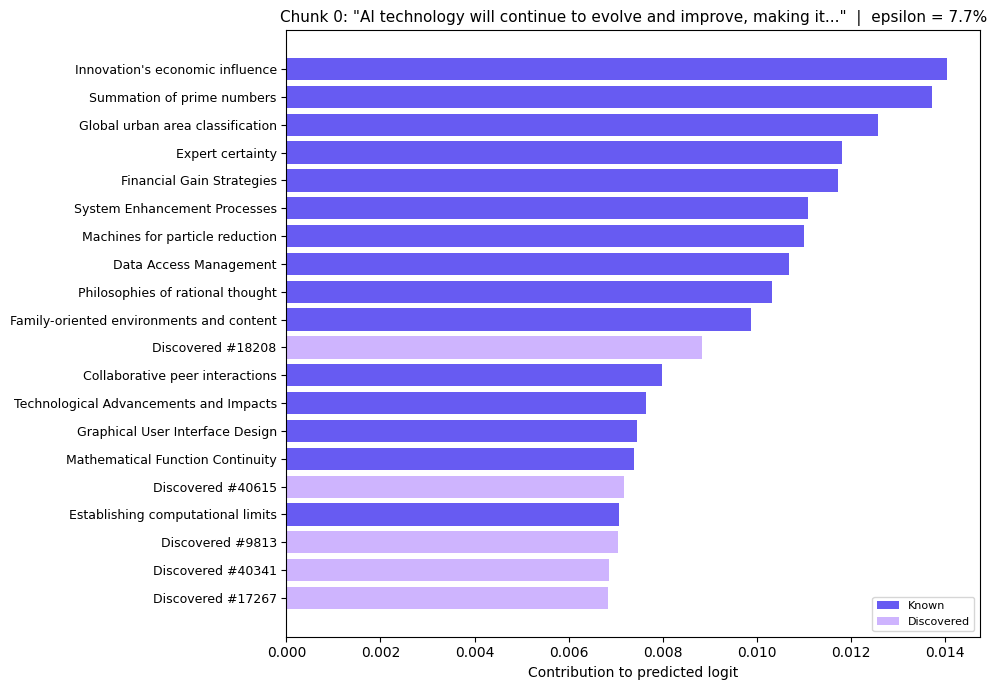

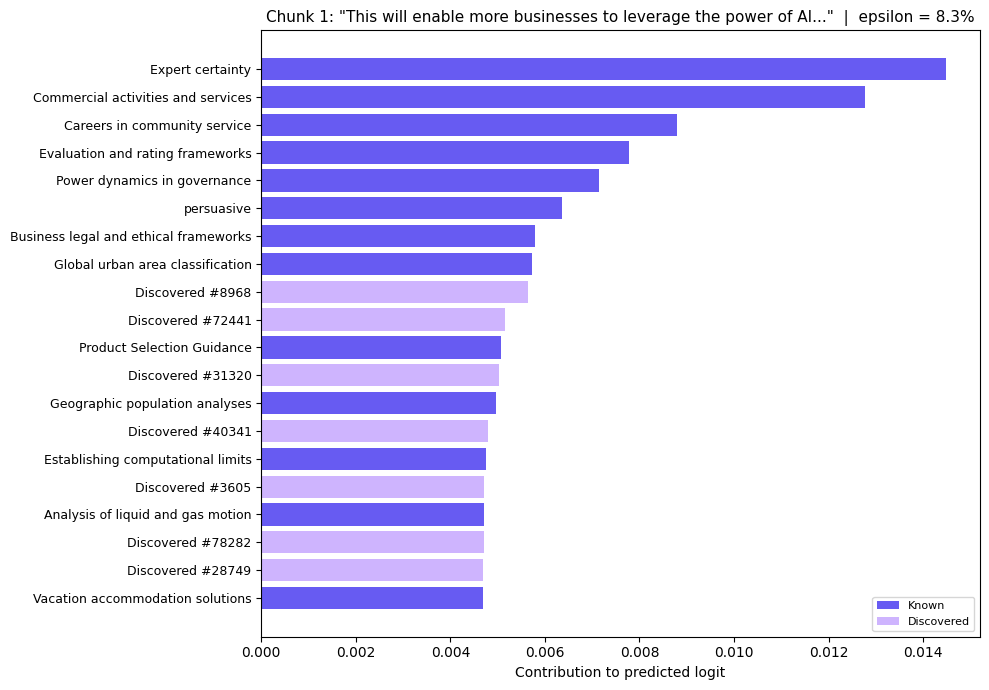

In [8]:
# Plot concept attribution for the first two chunks
for i, (s, e) in enumerate(chunks[:2]):
    text_preview = tokenizer.decode(output[0, s:e].tolist())[:60]
    entries, eps_pct = chunk_attribution(attr, s, e)
    plot_contributions(entries, title=f"Chunk {i}: \"{text_preview}...\"", eps_pct=eps_pct, top_k=20)

## 5. Explore a Concept

What vocabulary tokens does a specific concept "care about"? We compute the dot product
of a concept's embedding with every row of the LM head to find the tokens it most strongly
activates. This helps build intuition about what each concept represents.

In [9]:
@torch.no_grad()
def concept_top_tokens(concept_id, concept_type="known", top_k=20):
    """Find the vocabulary tokens most favored by a concept embedding."""
    head = backbone.known_head if concept_type == "known" else backbone.unknown_head
    emb = head._get_embedding(torch.tensor([concept_id], device=device)).squeeze(0)
    W = backbone.transformer.lm_head.weight
    scores = (W @ emb.to(W.dtype)).float()

    vals, idx = scores.abs().topk(top_k)
    return [(tokenizer.decode([i.item()]), float(scores[i])) for i, _ in zip(idx, vals)]


# Show top tokens for a few known concepts
for cid in [0, 1, 5]:
    label = concept_label(cid, "known")
    tokens = concept_top_tokens(cid, "known")
    print(f"\n{label} (Known #{cid}):")
    for tok, score in tokens[:10]:
        print(f"  {'+'if score>0 else '-'} {tok!r:>20s}  score={score:+.4f}")


Block size specifications (Known #0):
  +             ' block'  score=+3.3906
  +            ' blocks'  score=+3.1250
  +             ' Block'  score=+2.8906
  +              'block'  score=+2.5938
  +            ' Blocks'  score=+2.5469
  +             ' BLOCK'  score=+2.5312
  +              'Block'  score=+2.4062
  +             '-block'  score=+2.3438
  +             'blocks'  score=+2.2969
  +             'Blocks'  score=+2.2344

Ultra-wide-angle imaging technology (Known #1):
  +               'Wide'  score=+1.4922
  +              ' Wide'  score=+1.4453
  +                 'ye'  score=+1.4453
  +               'amas'  score=+1.4219
  +            '-degree'  score=+1.3906
  +               ' fis'  score=+1.3750
  +             ' panor'  score=+1.3516
  +             '-angle'  score=+1.3438
  +                 'he'  score=+1.3359
  +             ' stere'  score=+1.3281

Calendar year structuring (Known #5):
  +           ' century'  score=+1.6094
  +              ' leap'  score=+